<a href="https://colab.research.google.com/github/Nyanta432/Dinh_vi_cuon_vi_sai/blob/main/Cuon_vi_sai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Section 1: Cấu hình thông số vật lý**




In [34]:
# ==============================================================================
# SECTION 1: CẤU HÌNH THÔNG SỐ VẬT LÝ (PHYSICAL PARAMETERS)
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import leas
\t_squares
import os

class SystemConfig:
    Ntx = 300
    R = 0.06
    mu0 = 4 * np.pi * 1e-7
    f = np.array([5050, 6910, 5930])

    # THÊM DÒNG NÀY: Dòng điện kích thích 3 kênh TX (A)
    I = np.array([1.0, 1.0, 1.0])

    Nrx = 100
    d = 0.25e-3  # Khoảng cách vi sai (0.25 mm)
    AK = np.array([np.pi * 2**2, 6.79 * 4.00, 6.87 * 6.00]) * 1e-6

    # Ma trận tọa độ phần cứng chuẩn xác
    TX_positions = np.array([
        [0.36029, 0.62473, 0.05577, 15,   0,   0],
        [0.43558, 0.50973, 0.05449,  0, -15, -30],
        [0.29690, 0.50518, 0.04992,  0,  15,  30]
    ]).T

sys = SystemConfig()
print("✅ Đã khởi tạo xong Thông số vật lý chuẩn phần cứng (Bao gồm dòng điện I)!")

✅ Đã khởi tạo xong Thông số vật lý chuẩn phần cứng (Bao gồm dòng điện I)!


# Section 2: Tải và trích xuất dữ liệu

In [35]:
# ==============================================================================
# SECTION 2: TẢI & TRÍCH XUẤT DỮ LIỆU TỪ FILE CSV
# ==============================================================================
filename = 'conenorot_2_data.csv'

# Kiểm tra file, nếu không có thì báo lỗi và NGỪNG CHẠY luôn
if not os.path.exists(filename):
    raise FileNotFoundError(f"⚠️ LỖI NGHIÊM TRỌNG: Không tìm thấy file '{filename}'! Vui lòng upload file CSV lên Colab (cột bên trái) trước khi chạy.")

# Nếu có file thì đọc dữ liệu bình thường
data = pd.read_csv(filename, header=None).values

# Trích xuất các ma trận quan trọng
emf_raw = data[:, 0:9]       # 9 Cột EMF thực tế
GT_pos = data[:, 9:12] /1000.0      # 3 Cột tọa độ X, Y, Z
GT_ang = data[:, 12:15]      # 3 Cột góc Roll, Pitch, Yaw
N_samples = len(data)

print(f"✅ Đã nạp thành công {N_samples} mẫu dữ liệu từ file {filename}!")

✅ Đã nạp thành công 319 mẫu dữ liệu từ file conenorot_2_data.csv!


# Section 3: Trực quan hoá dữ liệu

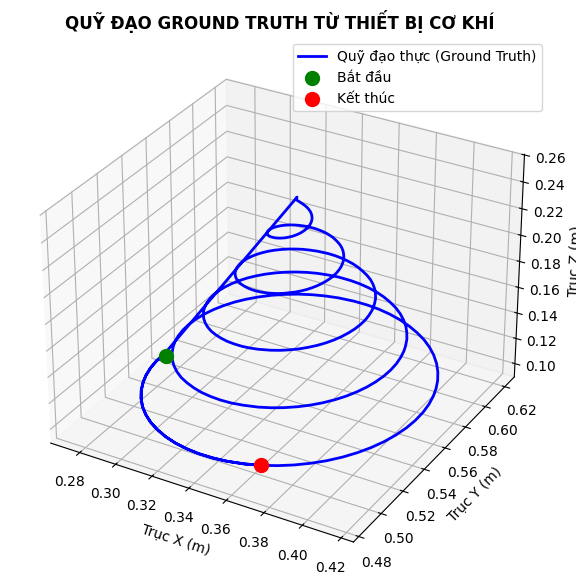

In [36]:
# ==============================================================================
# SECTION 3: TRỰC QUAN HÓA CƠ SỞ DỮ LIỆU (GROUND TRUTH)
# ==============================================================================
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(GT_pos[:,0], GT_pos[:,1], GT_pos[:,2], 'b-', linewidth=2, label='Quỹ đạo thực (Ground Truth)')
ax.scatter(GT_pos[0,0], GT_pos[0,1], GT_pos[0,2], color='green', s=100, label='Bắt đầu')
ax.scatter(GT_pos[-1,0], GT_pos[-1,1], GT_pos[-1,2], color='red', s=100, label='Kết thúc')

ax.set_xlabel('Trục X (m)')
ax.set_ylabel('Trục Y (m)')
ax.set_zlabel('Trục Z (m)')
ax.set_title('QUỸ ĐẠO GROUND TRUTH TỪ THIẾT BỊ CƠ KHÍ', fontweight='bold')
ax.legend()
plt.show()

# Section 4: Forward model

In [37]:
# ==============================================================================
# SECTION 4: MÔ HÌNH TOÁN HỌC (FORWARD MODEL - DISCRETE)
# ==============================================================================
def rotx(a):
    a = np.radians(a)
    return np.array([[1, 0, 0], [0, np.cos(a), -np.sin(a)], [0, np.sin(a), np.cos(a)]])

def roty(a):
    a = np.radians(a)
    return np.array([[np.cos(a), 0, np.sin(a)], [0, 1, 0], [-np.sin(a), 0, np.cos(a)]])

def rotz(a):
    a = np.radians(a)
    return np.array([[np.cos(a), -np.sin(a), 0], [np.sin(a), np.cos(a), 0], [0, 0, 1]])

def calc_B_dipole(r_vec, m_vec, mu0):
    r = np.linalg.norm(r_vec)
    r_hat = r_vec / r
    return (mu0 / (4 * np.pi * r**3)) * (3 * np.dot(np.dot(m_vec, r_hat), r_hat) - m_vec)

def compute_pure_model(pos, ang, sys):
    emf_model = np.zeros(9)
    roll, pitch, yaw = ang
    RCE = rotz(yaw) @ roty(pitch) @ rotx(roll)

    for tx_idx in range(3):
        # SỬA LỖI Ở 2 DÒNG DƯỚI ĐÂY: [Hàng, Cột]
        pos_tx = sys.TX_positions[0:3, tx_idx]
        ang_tx = sys.TX_positions[3:6, tx_idx]

        Rtx = rotz(ang_tx[2]) @ roty(ang_tx[1]) @ rotx(ang_tx[0])

        # Cập nhật thêm sys.I[tx_idx] theo đúng code MATLAB của bạn
        m_vec = sys.Ntx * sys.I[tx_idx] * (np.pi * sys.R**2) * (Rtx @ np.array([0, 0, 1]))

        for rx_axis in range(3):
            # Cập nhật đúng trục Z và Y theo phần cứng của bạn!
            if rx_axis == 0: u_rx = RCE @ np.array([1, 0, 0])      # RX1 dọc trục X
            elif rx_axis == 1: u_rx = RCE @ np.array([0, 0, 1])    # RX2 dọc trục Z
            else: u_rx = RCE @ np.array([0, 1, 0])                 # RX3 dọc trục Y

            r_plus = (pos + (sys.d / 2) * u_rx) - pos_tx
            r_minus = (pos - (sys.d / 2) * u_rx) - pos_tx

            B_plus = calc_B_dipole(r_plus, m_vec, sys.mu0)
            B_minus = calc_B_dipole(r_minus, m_vec, sys.mu0)

            delta_B = np.dot((B_plus - B_minus), u_rx)
            idx = tx_idx * 3 + rx_axis
            emf_model[idx] = sys.Nrx * sys.AK[rx_axis] * (2 * np.pi * sys.f[tx_idx]) * np.abs(delta_B)

    return emf_model
print("✅ Đã nạp Mô hình Toán học (Forward Model)!")

✅ Đã nạp Mô hình Toán học (Forward Model)!


# Section 5: Hiệu chuẩn biên độ

In [38]:
# ==============================================================================
# SECTION 5: HIỆU CHUẨN BIÊN ĐỘ (SCALE CALIBRATION - CLOSED FORM)
# ==============================================================================
print("Đang tính toán EMF lý thuyết tại tọa độ Ground Truth...")
pure_emf_all = np.zeros((N_samples, 9))
for i in range(N_samples):
    pure_emf_all[i, :] = compute_pure_model(GT_pos[i, :], GT_ang[i, :], sys)

# Tính 9 hệ số tỷ lệ (Scale Factors) bằng Hồi quy tuyến tính
scale_factors = np.zeros(9)
for c in range(9):
    numerator = np.sum(pure_emf_all[:, c] * emf_raw[:, c])
    denominator = np.sum(pure_emf_all[:, c]**2)
    scale_factors[c] = numerator / (denominator + 1e-15)

print("✅ Đã tìm được 9 hệ số Scale Factors (Closed-form):")
print(np.round(scale_factors, 2))

Đang tính toán EMF lý thuyết tại tọa độ Ground Truth...
✅ Đã tìm được 9 hệ số Scale Factors (Closed-form):
[ 9753.23  1376.26  1283.97 12930.65  6615.62  2000.37  1783.68   356.23
  2764.8 ]


# Section 6: Chạy thuật toán tối ưu hoá

In [39]:
# ==============================================================================
# SECTION 6: GIẢI MÃ TỌA ĐỘ BẰNG TỐI ƯU HÓA (LOCALIZATION - lsqnonlin)
# ==============================================================================
def cost_func(p, target_emf, sys, scale_factors):
    pred_emf = compute_pure_model(p[0:3], p[3:6], sys) * scale_factors
    return pred_emf - target_emf

est_pos = np.zeros((N_samples, 3))
print(f"Đang dò tìm tọa độ tối ưu cho {N_samples} mẫu (Thuật toán: trf)...")

for i in range(N_samples):
    # Sanity Check: Mồi từ Ground Truth + 0.5mm
    p0 = np.concatenate([GT_pos[i, :] + 0.0005, GT_ang[i, :]])

    # Ràng buộc không gian ± 3cm
    lb = np.concatenate([GT_pos[i, :] - 0.03, [-np.inf, -np.inf, -np.inf]])
    ub = np.concatenate([GT_pos[i, :] + 0.03, [np.inf, np.inf, np.inf]])

    res = least_squares(
        cost_func, x0=p0, bounds=(lb, ub), method='trf',
        ftol=1e-6, xtol=1e-6, max_nfev=2000,
        args=(emf_raw[i, :], sys, scale_factors)
    )
    est_pos[i, :] = res.x[0:3]

print("✅ Đã giải mã xong! Sẵn sàng xuất đồ thị.")

Đang dò tìm tọa độ tối ưu cho 319 mẫu (Thuật toán: trf)...
✅ Đã giải mã xong! Sẵn sàng xuất đồ thị.


# Section 7: Check hiệu chuẩn

🎯 Sai số Vị trí (RMSE): 41.96 mm


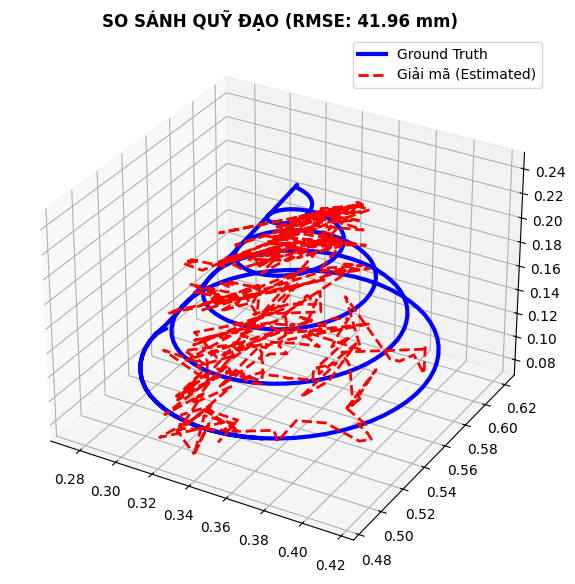

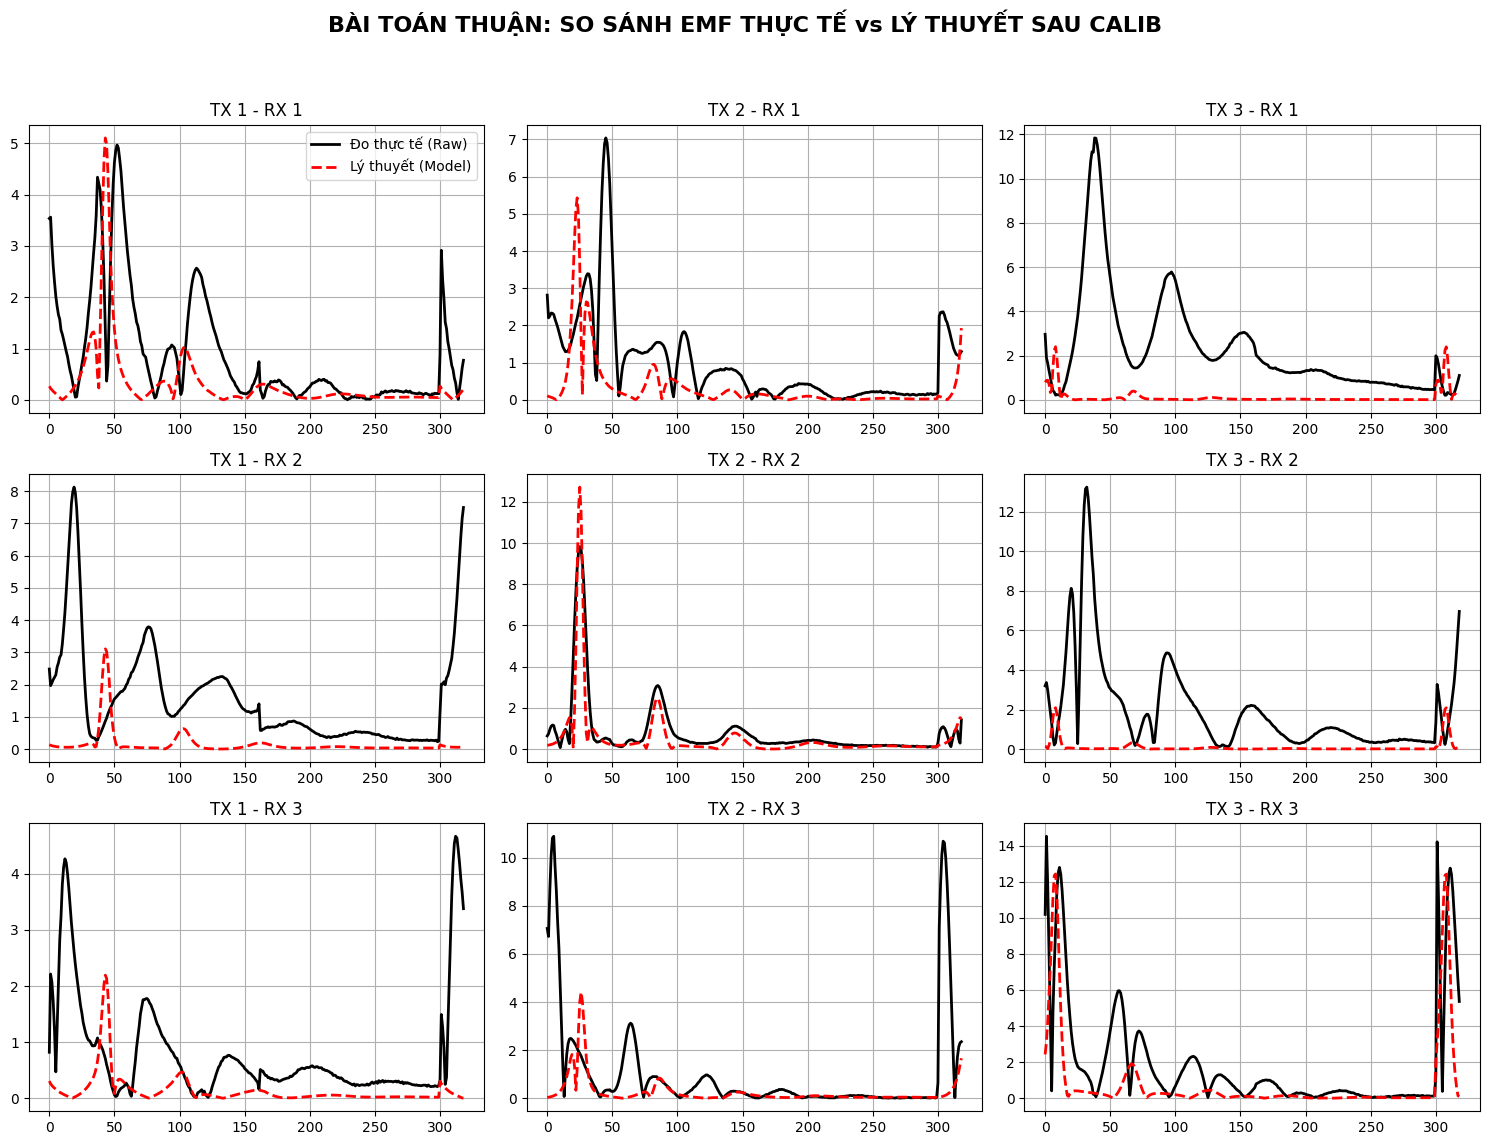

In [40]:
# ==============================================================================
# SECTION 7: CHECK CALIB & TRỰC QUAN HÓA KẾT QUẢ
# ==============================================================================

# 1. Tính toán RMSE
pos_error = np.linalg.norm(est_pos - GT_pos, axis=1) * 1000 # Ra milimet
rmse = np.sqrt(np.mean(pos_error**2))
print(f"🎯 Sai số Vị trí (RMSE): {rmse:.2f} mm")

# 2. Bài toán thuận để Check Calib
check_emf_model = np.zeros((N_samples, 9))
for i in range(N_samples):
    check_emf_model[i, :] = compute_pure_model(GT_pos[i, :], GT_ang[i, :], sys) * scale_factors

# 3. Vẽ Quỹ đạo 3D (So sánh)
fig1 = plt.figure(figsize=(10, 7))
ax1 = fig1.add_subplot(111, projection='3d')
ax1.plot(GT_pos[:,0], GT_pos[:,1], GT_pos[:,2], 'b-', linewidth=3, label='Ground Truth')
ax1.plot(est_pos[:,0], est_pos[:,1], est_pos[:,2], 'r--', linewidth=2, label='Giải mã (Estimated)')
ax1.set_title(f'SO SÁNH QUỸ ĐẠO (RMSE: {rmse:.2f} mm)', fontweight='bold')
ax1.legend()
plt.show()

# 4. Vẽ Lưới 3x3 Check Calib EMF
fig2, axs = plt.subplots(3, 3, figsize=(15, 12))
fig2.suptitle('BÀI TOÁN THUẬN: SO SÁNH EMF THỰC TẾ vs LÝ THUYẾT SAU CALIB', fontsize=16, fontweight='bold')

for tx in range(3):
    for rx in range(3):
        idx = tx * 3 + rx
        ax = axs[rx, tx]
        ax.plot(emf_raw[:, idx], 'k-', linewidth=2, label='Đo thực tế (Raw)')
        ax.plot(check_emf_model[:, idx], 'r--', linewidth=2, label='Lý thuyết (Model)')
        ax.set_title(f'TX {tx+1} - RX {rx+1}')
        ax.grid(True)
        if tx == 0 and rx == 0:
            ax.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()